# 05 — DOMINANT vs GAD-NR: Grafo de Miembros (M)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de miembros `M`
usando la librería **PyGOD 1.1.0**:

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## ¿Por qué este par de modelos?

Ambos pertenecen a la misma familia arquitectónica (GNN + Autoencoder, no supervisado) y
operan sobre el mismo objeto `Data` de PyG, lo que hace la comparativa limpia y directa.
La diferencia fundamental está en **qué reconstruyen**:

| Modelo | Reconstruye | Detecta bien |
|--------|------------|---------------|
| DOMINANT | Adyacencia $\hat{A}$ + features $\hat{X}$ | Anomalías estructurales y de atributos por separado |
| GAD-NR | Vecindario completo (features, grado, distribución de vecinos) | Anomalías contextuales, estructurales y joint-type |

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo M |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Guardado de resultados |

## 0. Imports y configuración

In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


In [2]:
print(torch.version.cuda)

12.1


## 1. Carga del grafo M

Cargamos el objeto `Data` del grafo M generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `member_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.

In [2]:
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)
print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
member_ids = data_M.member_ids  # lista de member_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_M_clean = Data(
    x=data_M.x,
    edge_index=data_M.edge_index,
)
print(f'\ndata_M_clean: {data_M_clean}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas únicas : 1176024
Features/nodo  : 3

data_M_clean: Data(x=[11371, 3], edge_index=[2, 2352048])


In [3]:
# Metadatos de miembros para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))

# DataFrame base indexado por member_id — se enriquecerá con los scores
id_to_idx = {mid: i for i, mid in enumerate(member_ids)}
base_df = pd.DataFrame({'member_id': member_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_M.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_M.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()

base_df: (11371, 6)


,member_id,idx,name,city,state,degree
0,2069,0,Wesley Duffee-Braun,Brentwood,TN,219
1,8386,1,Tim,Nashville,TN,307
2,9205,2,Brenda,Brentwood,TN,334
3,42506,3,Chris Meador,Nashville,TN,122
4,106758,4,Kt,Antioch,TN,119


## 2. Fundamento teórico: DOMINANT y GAD-NR

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR parte de la limitación clave de DOMINANT y los GAE clásicos: al reconstruir solo
los enlaces directos, los nodos conectados se agrupan en el espacio latente, lo que hace
que el modelo sea bueno detectando anomalías de tipo cluster pero no anomalías más complejas.

La solución es reconstruir el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

La pérdida total combina las tres con pesos `lambda_loss1` (vecindario), `lambda_loss2` (features)
y `lambda_loss3` (grado). El anomaly score final es la combinación ponderada de las tres pérdidas
por nodo.

### 2.3 Hiperparámetros para el grafo M

| Hiperparámetro | DOMINANT | GAD-NR | Justificación |
|---|---|---|---|
| `hid_dim` | 64 | 64 | Dimensión latente estándar |
| `num_layers` | 4 | 1 | DOMINANT: 2 enc + 2 dec. GAD-NR: encoder ligero, decoders MLP |
| `dropout` | 0.0 | 0.0 | Grafo grande, sin riesgo significativo de sobreajuste |
| `weight` / — | 0.2 | — | DOMINANT: más peso a estructura (0.8) que a atributos (0.2), justificado porque M solo tiene 3 features geográficas frente a >1M aristas |
| `lambda_loss1/2/3` | — | 0.01/0.1/0.8 | GAD-NR: defaults del paper — más peso al grado que al vecindario |
| `epoch` | 200 | 200 | Convergencia suficiente para ambos modelos |
| `lr` | 0.004 | 0.01 | Defaults de PyGOD para cada modelo |
| `contamination` | 0.05 | 0.05 | P95 como umbral — 5% de anomalías esperadas |
| `batch_size` | 0 | 0 | Full batch — 11.371 nodos es manejable |
| `save_emb` | True | True | Guardar embeddings para análisis posterior |

## 3. Entrenamiento de DOMINANT

PyGOD usa una API similar a scikit-learn: se instancia el detector con los hiperparámetros
y se llama a `fit(data)`. Los scores quedan en `detector.decision_score_` y las etiquetas
binarias en `detector.label_` (determinadas por `contamination`).

Para acceder a los scores de estructura y atributo por separado realizamos un forward pass manual con el modelo interno `detector.model` tras el entrenamiento.

In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.2,         # peso del error de atributo: bajo porque M tiene solo 3 features
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=200,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo M...')
dominant.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')

Entrenando DOMINANT sobre el grafo M...
Epoch 0000: Loss 10.4131 |  | Time 2.55
Epoch 0001: Loss 10.3505 |  | Time 0.36
Epoch 0002: Loss 10.3175 |  | Time 0.29
Epoch 0003: Loss 10.3266 |  | Time 0.29
Epoch 0004: Loss 10.3100 |  | Time 0.29
Epoch 0005: Loss 10.3069 |  | Time 0.28
Epoch 0006: Loss 10.2925 |  | Time 0.27
Epoch 0007: Loss 10.2915 |  | Time 0.29
Epoch 0008: Loss 10.2700 |  | Time 0.29
Epoch 0009: Loss 10.2588 |  | Time 0.29
Epoch 0010: Loss 10.2523 |  | Time 0.27
Epoch 0011: Loss 10.2477 |  | Time 0.28
Epoch 0012: Loss 10.2322 |  | Time 0.28
Epoch 0013: Loss 10.2183 |  | Time 0.27
Epoch 0014: Loss 10.2056 |  | Time 0.28
Epoch 0015: Loss 10.1993 |  | Time 0.27
Epoch 0016: Loss 10.1893 |  | Time 0.27
Epoch 0017: Loss 10.1825 |  | Time 0.27
Epoch 0018: Loss 10.1741 |  | Time 0.29
Epoch 0019: Loss 10.1654 |  | Time 0.28
Epoch 0020: Loss 10.1589 |  | Time 0.27
Epoch 0021: Loss 10.1489 |  | Time 0.28
Epoch 0022: Loss 10.1460 |  | Time 0.28
Epoch 0023: Loss 10.1414 |  | Time 0.28


In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo por separado desde DOMINANT.

    DOMINANTBase.forward() devuelve (x_hat, s_hat) donde:
      x_hat : features reconstruidas [N, in_dim]
      s_hat : adyacencia reconstruida densa [N, N]  (generada por process_graph)

    Returns
    -------
    struct_scores : np.ndarray [N]  — MSE por fila de A
    attr_scores   : np.ndarray [N]  — MSE por nodo en features
    """
    model = detector.model
    model.eval()

    # process_graph añade la adyacencia densa data.s al objeto Data
    data_proc = data.clone()
    model.process_graph(data_proc)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)  # adyacencia densa real [N, N]

    # Forward: devuelve (x_hat, s_hat)
    x_hat, s_hat = model(x, edge_index)

    # Error de atributo por nodo: MSE entre X real y X reconstruida
    attr_scores   = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()

    # Error de estructura por nodo: MSE entre fila real y fila reconstruida de A
    struct_scores = ((s_real - s_hat) ** 2).mean(dim=1).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.6f}, max={dom_struct.max():.6f}, mean={dom_struct.mean():.6f}')
print(f'DOM attr   — min={dom_attr.min():.6f},  max={dom_attr.max():.6f},  mean={dom_attr.mean():.6f}')

# Verificación: el score combinado debe coincidir con (1-weight)*struct + weight*attr
score_check = (1 - dominant.weight) * dom_struct + dominant.weight * dom_attr
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación fórmula combinada — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=0.000230, max=0.142423, mean=0.015588
DOM attr   — min=0.000002,  max=606.248291,  mean=0.909491

Verificación fórmula combinada — correlación con decision_score_: 0.038633
(debería ser ~1.0)


In [6]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=1.6173, max=40.2429, mean=12.1251
DOM attr   — min=0.0026,  max=42.6467,  mean=0.7430

Verificación — correlación con decision_score_: 0.999986
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_score_distributions_M.png


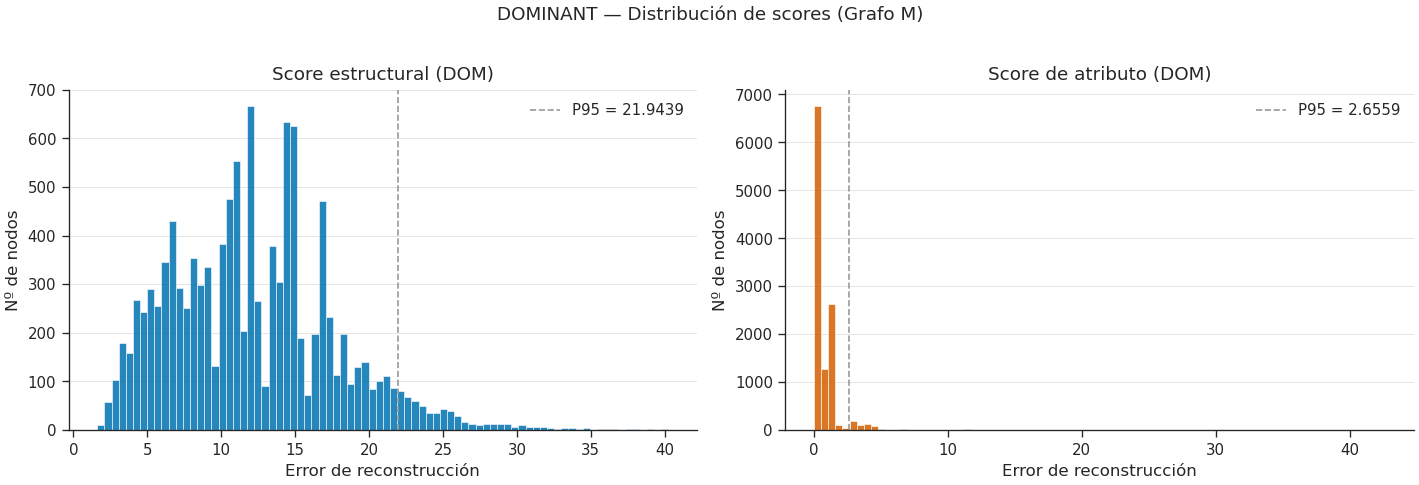

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.0409


In [7]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['M'], PALETTE['anomaly']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['neutral'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo M)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_dominant_score_distributions_M.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')

## 4. Entrenamiento de GAD-NR

GAD-NR tiene una arquitectura más compleja que DOMINANT. El encoder combina un MLP de
reducción de dimensionalidad seguido de un GNN de paso de mensajes. El decoder tiene tres
cabezas independientes: un MLP para las features propias, un MLP para el grado, y una
distribución Gaussiana para los atributos de los vecinos.

**Nota sobre `num_layers=1`:** en GAD-NR este parámetro controla el número de capas del
*encoder GNN*, no del modelo completo. El paper original usa 1 capa de encoder — añadir
más capas aumenta el over-smoothing y degrada la detección. Los decoders tienen sus propios
parámetros (`deg_dec_layers=4`, `fea_dec_layers=3`).

**Nota sobre `lambda_loss`:** los valores por defecto del paper son los que usa PyGOD:
`lambda_loss1=0.01` (vecindario), `lambda_loss2=0.1` (features), `lambda_loss3=0.8` (grado).
El grado recibe el mayor peso porque es la señal más robusta para detectar nodos con
patrones de conectividad anómalos.

In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [10]:
gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper original
    deg_dec_layers=4,       # capas del decoder de grado
    fea_dec_layers=3,       # capas del decoder de features
    sample_size=2,          # muestras para la distribución de vecinos
    sample_time=3,          # repeticiones de muestreo para reducir ruido
    neigh_loss='KL',        # KL divergence para la distribución de vecinos
    lambda_loss1=0.01,      # peso del loss de vecindario
    lambda_loss2=0.1,       # peso del loss de features
    lambda_loss3=0.8,       # peso del loss de grado
    real_loss=True,
    contamination=0.05,     # P95 — consistente con DOMINANT
    lr=0.0005,
    epoch=200,
    dropout=0.0,
    weight_decay=0.0003,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,           # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo M...')
gadnr.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')

Entrenando GAD-NR sobre el grafo M...
Epoch 0001: Loss 67212.8828 |  | Time 3.25
Epoch 0002: Loss 67093.4219 |  | Time 1.74
Epoch 0003: Loss 66985.4844 |  | Time 1.69
Epoch 0004: Loss 66910.6562 |  | Time 1.70
Epoch 0005: Loss 66840.2578 |  | Time 1.70
Epoch 0006: Loss 66767.8828 |  | Time 1.72
Epoch 0007: Loss 66692.8125 |  | Time 1.94
Epoch 0008: Loss 66612.3672 |  | Time 1.67
Epoch 0009: Loss 66526.6484 |  | Time 1.64
Epoch 0010: Loss 66436.7578 |  | Time 1.65
Epoch 0011: Loss 66341.4922 |  | Time 1.63
Epoch 0012: Loss 66240.0000 |  | Time 1.65
Epoch 0013: Loss 66132.2578 |  | Time 1.65
Epoch 0014: Loss 66018.7969 |  | Time 1.65
Epoch 0015: Loss 65898.7500 |  | Time 1.64
Epoch 0016: Loss 65770.7891 |  | Time 1.63
Epoch 0017: Loss 65628.8281 |  | Time 1.63
Epoch 0018: Loss 65472.0000 |  | Time 1.64
Epoch 0019: Loss 65297.3867 |  | Time 1.67
Epoch 0020: Loss 32556.5391 |  | Time 1.67
Epoch 0021: Loss 32462.9180 |  | Time 1.68
Epoch 0022: Loss 32367.2305 |  | Time 1.63
Epoch 0023: Loss

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    Returns
    -------
    h_loss      : np.ndarray [N] — divergencia KL de distribución de vecinos
    degree_loss : np.ndarray [N] — error de reconstrucción de grado
    feat_loss   : np.ndarray [N] — error de reconstrucción de features propias
    """
    detector.model.eval()

    data.x          = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.cpu().numpy(),
            degree_loss.cpu().numpy(),
            feat_loss.cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f},  max={gadnr_feat.max():.4f}')

GAD-NR vecindario (KL) — min=0.3257,   max=4.2975
GAD-NR grado           — min=0.0036, max=848263.5000
GAD-NR features        — min=0.0635,  max=0.2755


In [12]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss_per_node      — divergencia KL de distribución de vecinos
      degree_loss_per_node — error de reconstrucción de grado
      feature_loss_per_node— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
# con los lambdas FINALES del modelo tras el curriculum
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

GAD-NR vecindario (KL) — min=0.3994,   max=4.2342,   mean=1.4660
GAD-NR grado           — min=0.0036, max=848263.6875, mean=16606.4824
GAD-NR features        — min=0.0635, max=0.2755, mean=0.1242

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.01
  lambda_loss2 (features)  : 5.1
  lambda_loss3 (grado)     : 0.00078125

Verificación — correlación con decision_score_: 0.951099
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distribution_M.png


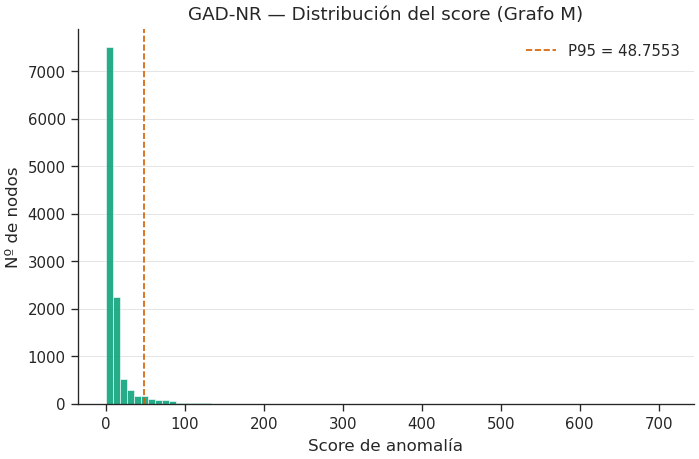

In [13]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_score_distribution_M.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distributions_M.png


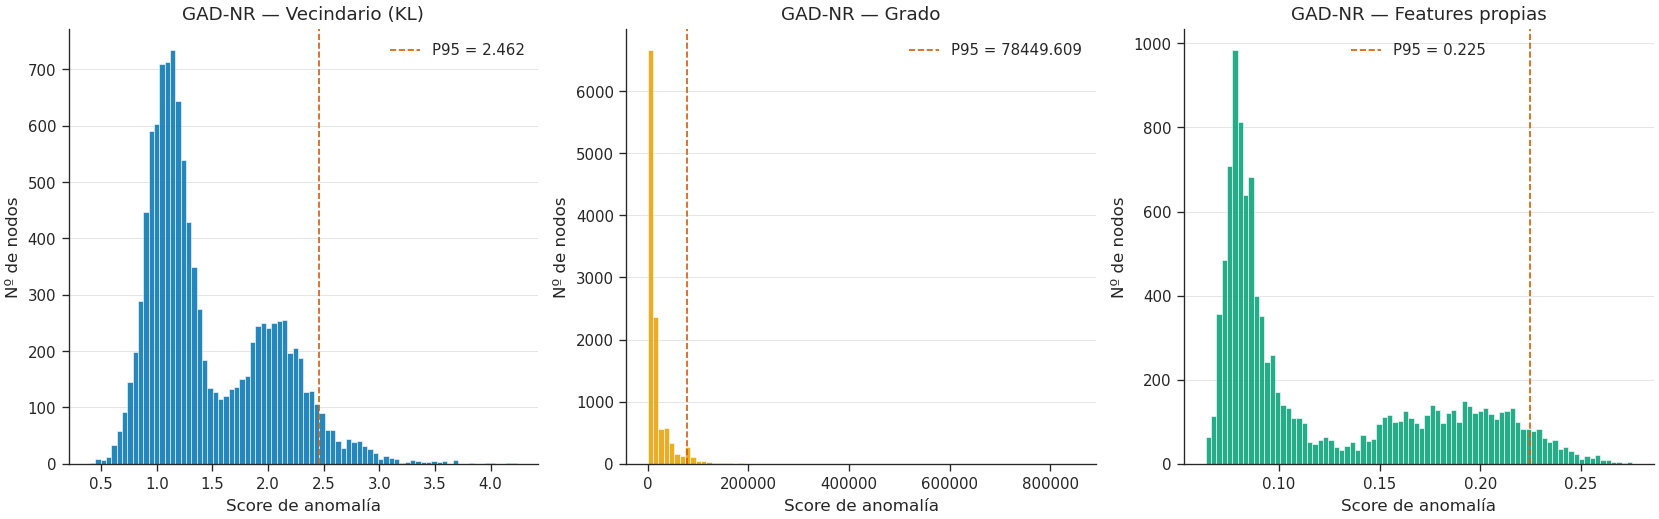

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = -0.0293
  Vecindario vs Features: ρ = 0.6471
  Grado      vs Features: ρ = 0.0239


In [14]:
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  CAT_COLORS[0]),
    (gadnr_deg,  'Grado',            CAT_COLORS[1]),
    (gadnr_feat, 'Features propias', CAT_COLORS[2]),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '05_gadnr_score_distributions_M.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')

## 5. Comparativa por tipo de señal

Con los sub-scores extraídos de ambos modelos podemos hacer una comparativa
alineada con la taxonomía de anomalías de los papers originales
(Ding et al., 2019; Roy et al., 2024):

| Señal | Modelo | Tipo de anomalía |
|-------|--------|------------------|
|  | DOMINANT | Estructural — conectividad inusual |
|  | DOMINANT | Atributo — features distintas a la mayoría |
|  | GAD-NR | Estructural — grado inusual (señal análoga) |
|  | GAD-NR | Atributo — features distintas (señal análoga) |
|  | GAD-NR | **Joint-type** — features incompatibles con el vecindario |

La estructura de esta sección es:
1. Preparación del DataFrame con todos los sub-scores y percentiles
2. Comparativa estructural:  vs 
3. Comparativa de atributos:  vs 
4. Scatter de tipología por modelo (estilo referencia)
5. Análisis de la señal joint-type de GAD-NR (independiente)


In [15]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat
scores_df['gadnr_score'] = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (11371, 18)
Columnas: ['member_id', 'idx', 'name', 'city', 'state', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Comparamos  (error de reconstrucción de adyacencia de DOMINANT)
con  (error de reconstrucción de grado de GAD-NR). Ambas señales
capturan anomalías estructurales pero desde perspectivas distintas: DOMINANT
mide si los enlaces del nodo se pueden reconstruir, mientras que GAD-NR mide
si su grado es predecible desde su embedding.

Una correlación alta indicaría que ambos modelos detectan las mismas anomalías
estructurales. Una baja indicaría información complementaria.


In [18]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

# Solapamiento top-100
K = 100
top_dom_struct   = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg    = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct   = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')

# Top-10 exclusivos de cada modelo en señal estructural
only_dom_struct   = top_dom_struct - top_gadnr_deg
only_gadnr_deg    = top_gadnr_deg  - top_dom_struct
print(f'Exclusivos DOMINANT-struct : {len(only_dom_struct)}')
print(f'Exclusivos GAD-NR-deg      : {len(only_gadnr_deg)}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.7157
Solapamiento top-100: 41/100 nodos comunes (41%)
Exclusivos DOMINANT-struct : 59
Exclusivos GAD-NR-deg      : 59


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_structural_comparison_M.png


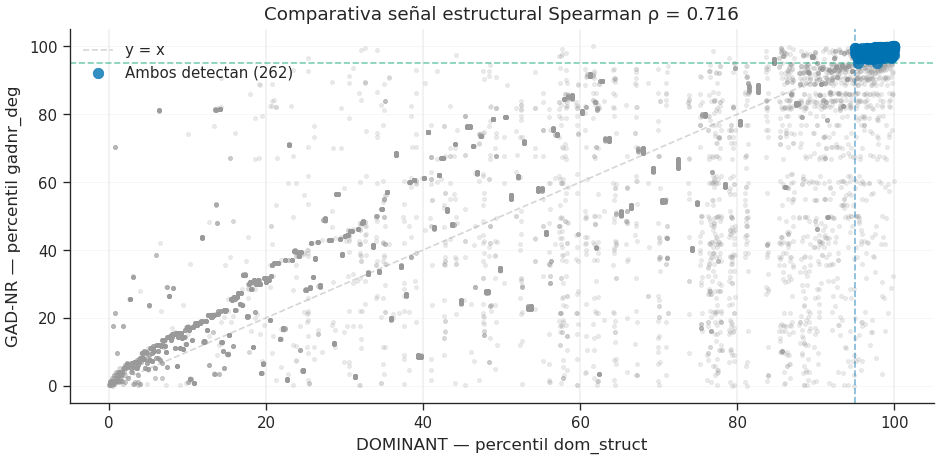

In [20]:
# Scatter comparativa estructural: dom_struct (X) vs gadnr_deg (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['M'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color=PALETTE['neutral'],
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

# Nodos que ambos detectan como estructurales
ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=40, alpha=0.8, color=PALETTE['M'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural Spearman ρ = {rho_struct:.3f}',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_structural_comparison_M.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Comparamos  (error de reconstrucción de features de DOMINANT)
con  (error de reconstrucción de features propias de GAD-NR).
Ambas señales miden si los atributos del nodo son inusuales, pero con
encoders distintos — DOMINANT usa un decoder GCN que reconstruye X desde Z,
mientras que GAD-NR usa un MLP que reconstruye las features iniciales desde
la representación final del nodo.


In [22]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

# Solapamiento top-100
top_dom_attr    = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat  = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr    = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')

only_dom_attr   = top_dom_attr  - top_gadnr_feat
only_gadnr_feat = top_gadnr_feat - top_dom_attr
print(f'Exclusivos DOMINANT-attr : {len(only_dom_attr)}')
print(f'Exclusivos GAD-NR-feat   : {len(only_gadnr_feat)}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.7842
Solapamiento top-100: 0/100 nodos comunes (0%)
Exclusivos DOMINANT-attr : 100
Exclusivos GAD-NR-feat   : 100


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_attribute_comparison_M.png


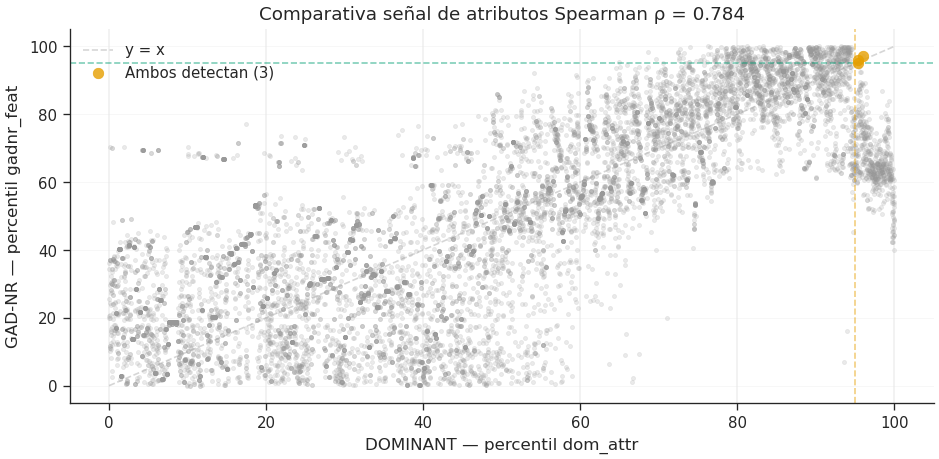

In [24]:
# Scatter comparativa de atributos: dom_attr (X) vs gadnr_feat (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['G'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['MG'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color=PALETTE['neutral'],
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

# Nodos que ambos detectan como atributo
ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=40, alpha=0.8, color=PALETTE['G'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos Spearman ρ = {rho_attr:.3f}',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_attribute_comparison_M.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Para cada modelo construimos el scatter estructural vs atributo con la
tipología de anomalías resultante, siguiendo el mismo estilo visual.

**DOMINANT:** usa sus dos señales propias ( vs ).
Solo puede detectar anomalías Estructurales, de Atributo y Mixtas.

**GAD-NR:** usa sus dos señales análogas ( vs ).
La comparación con DOMINANT revela si el modelo más avanzado redistribuye
los mismos nodos o detecta poblaciones distintas.


In [26]:
# Tipología DOMINANT: dom_struct vs dom_attr
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

# Tipología GAD-NR: gadnr_deg vs gadnr_feat
def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

print('=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         : 10250 (90.1%)
  Estructural    :   552 (4.9%)
  Atributo       :   552 (4.9%)
  Mixta          :    17 (0.1%)
=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         : 10268 (90.3%)
  Atributo       :   534 (4.7%)
  Estructural    :   534 (4.7%)
  Mixta          :    35 (0.3%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_anomaly_typology_M.png


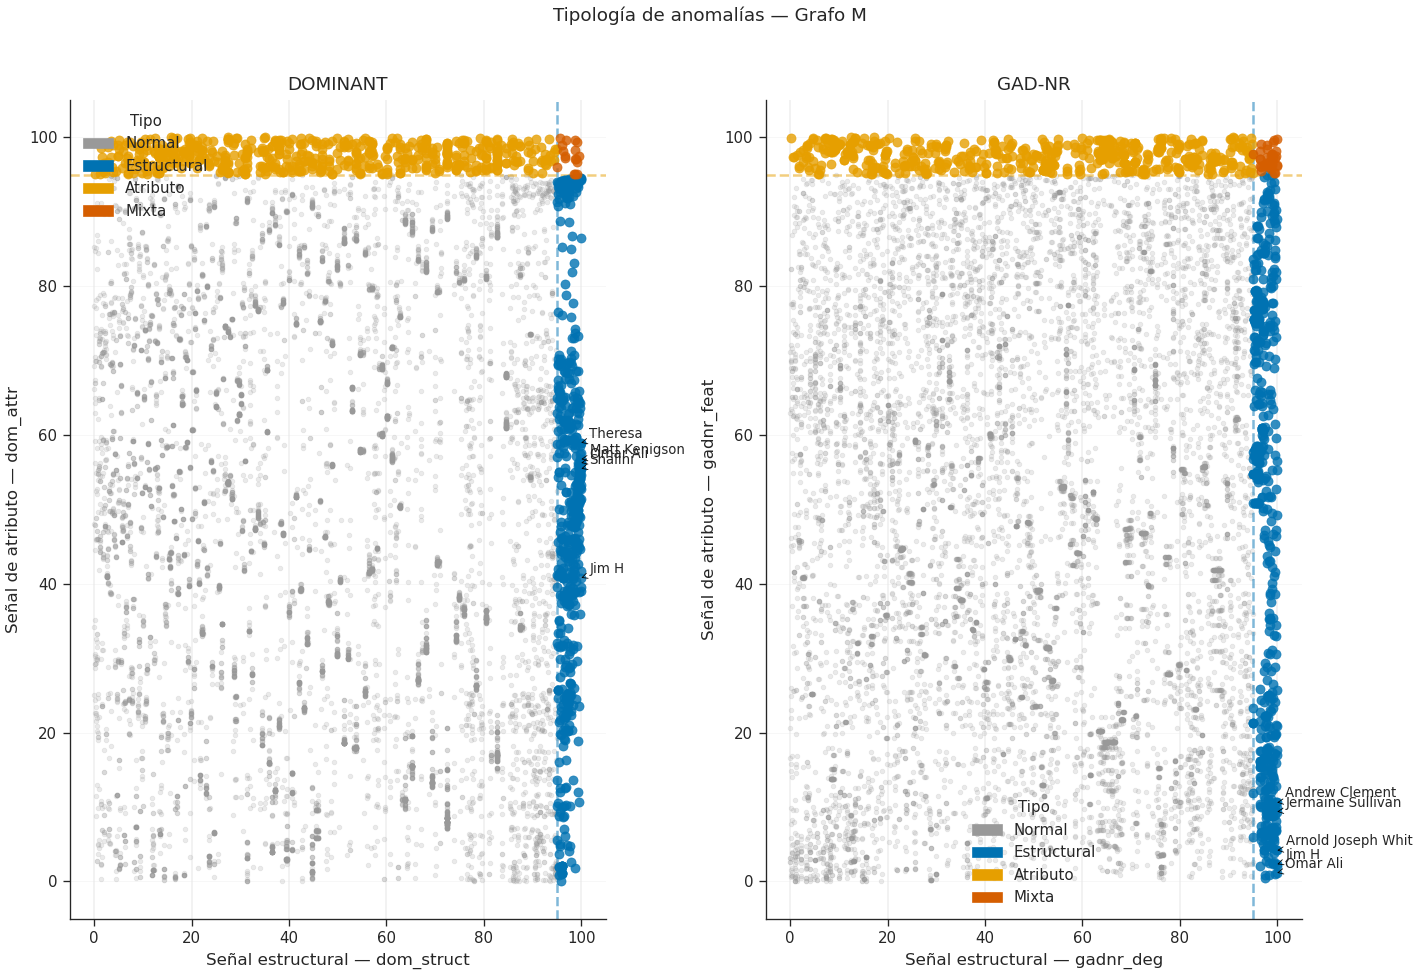

In [27]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {
    'Normal':      PALETTE['neutral'],
    'Estructural': PALETTE['M'],
    'Atributo':    PALETTE['G'],
    'Mixta':       PALETTE['anomaly'],
}

fig, axes = plt.subplots(1, 2, figsize=FS['r2c2'])

configs = [
    (axes[0], 'type_dom',   'pct_dom_struct',  'pct_dom_attr',
     'dom_combined', 'DOMINANT',
     'Señal estructural — dom_struct', 'Señal de atributo — dom_attr'),
    (axes[1], 'type_gadnr', 'pct_gadnr_deg',   'pct_gadnr_feat',
     'gadnr_score', 'GAD-NR',
     'Señal estructural — gadnr_deg', 'Señal de atributo — gadnr_feat'),
]

for ax, type_col, xcol, ycol, score_col, title, xlabel, ylabel in configs:
    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 30 if atype != 'Normal' else 8
        alpha  = 0.8 if atype != 'Normal' else 0.2
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=atype, zorder=zorder)

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--', alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--', alpha=0.5)

    # Top-5 por score del modelo
    top5 = scores_df.nlargest(5, score_col)
    for _, row in top5.iterrows():
        ax.annotate(
            str(row['name'])[:18],
            (row[xcol], row[ycol]),
            fontsize=FONT['annotation'],
            xytext=(5, 3), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.5)
        )

    legend_patches = [mpatches.Patch(color=color_map[t], label=t) for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo', fontsize=FONT['legend'], frameon=False)
    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title,   fontsize=FONT['title'])
    ax.grid(alpha=0.3)
    polish(ax)

plt.suptitle('Tipología de anomalías — Grafo M', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_anomaly_typology_M.png')
plt.show()


### 5.4 Señal joint-type de GAD-NR (análisis independiente)

La señal  — divergencia KL entre la distribución real de atributos
del vecindario y la reconstruida — es la única señal capaz de detectar
anomalías **joint-type**: nodos cuyas features son normales en sí mismas pero
no encajan con las features de sus vecinos.

Esta señal no tiene equivalente en DOMINANT. El análisis siguiente es
independiente y no compara con ninguna señal del otro modelo.


In [28]:
# Nodos con señal joint-type alta pero sin anomalía estructural ni de atributo
# según DOMINANT — los que DOMINANT no puede detectar
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Nodos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'city', 'state', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Nodos joint-type puros (invisibles para DOMINANT): 552
  Grado medio: 54.3 (vs 103.2 global)

Top-10 por gadnr_h:
                         name           city state  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
                Damon Kindred      La Vergne    TN       0        0.123120     62.984786   100.000000
Single Adult Ministry at BUMC      Brentwood    TN       1        0.479289     46.042564    99.991206
                        Chase      La Vergne    TN       4        1.925952     71.093132    99.982411
                   Ed Tingley Hendersonville    TN       1        1.037728     70.398382    99.973617
                 Lucinda Hall      Brentwood    TN       1        0.479289     46.042564    99.964823
              Patricia Wright      Brentwood    TN       4        1.736875     59.295576    99.956028
                    Kassandra   Murfreesboro    TN       4        1.736875     59.414300    99.947234
                    Will Buck Hendersonville    TN       0        0.26

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_joint_type_M.png


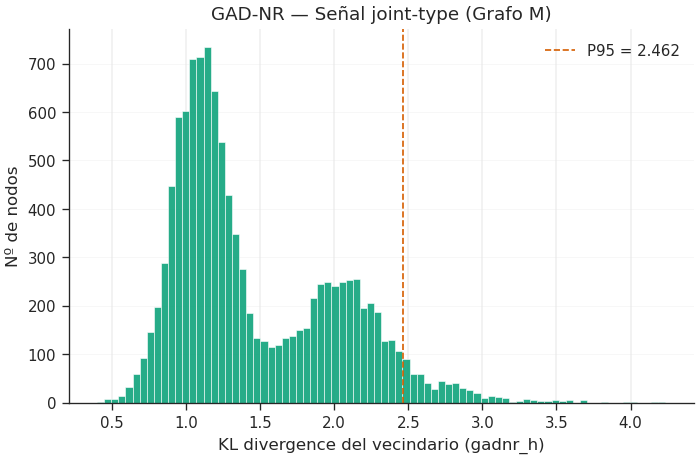

In [29]:
# Distribución del score joint-type
fig, ax = plt.subplots(figsize=FS['single'])

ax.hist(scores_df['gadnr_h'], bins=80,
        color=PALETTE['MG'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')

ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.grid(alpha=0.3)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_joint_type_M.png')
plt.show()


## 6. Spotlight — candidatos del EDA

Revisamos los candidatos identificados en el EDA con las cinco señales
disponibles. Para cada candidato mostramos el percentil en cada señal
y si supera el umbral P95.


In [32]:
def spotlight(name_fragment, df, label=None):
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):5d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):5d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):5d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):5d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):5d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)


CANDIDATOS DEL EDA — LAS 5 SEÑALES
  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688
    DOMINANT  estructural : #   14/11371  (99.9p) ⚠
    DOMINANT  atributo    : # 4667/11371  (59.0p)  
    GAD-NR    estructural : # 7691/11371  (32.4p)  
    GAD-NR    atributo    : #11042/11371  (2.9p)  
    GAD-NR    joint-type  : # 5694/11371  (49.9p)  

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955
    DOMINANT  estructural : #    2/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 5065/11371  (55.5p)  
    GAD-NR    estructural : #   12/11371  (99.9p) ⚠
    GAD-NR    atributo    : #11131/11371  (2.1p)  
    GAD-NR    joint-type  : # 9433/11371  (17.1p)  

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178
    DOMINANT  estructural : #    1/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 6732/11371  (40.8p)  
    GAD-NR    estructural : #    1/11371  (100.0p) ⚠
    GAD-NR    atributo   

In [33]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)
    def rank(col): return int((scores_df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ''

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'DOM-struct':     f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p){flag(row["pct_dom_struct"])}',
        'DOM-attr':       f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p){flag(row["pct_dom_attr"])}',
        'GADNR-struct':   f'#{rank("gadnr_deg")} ({row["pct_gadnr_deg"]:.0f}p){flag(row["pct_gadnr_deg"])}',
        'GADNR-attr':     f'#{rank("gadnr_feat")} ({row["pct_gadnr_feat"]:.0f}p){flag(row["pct_gadnr_feat"])}',
        'GADNR-joint':    f'#{rank("gadnr_h")} ({row["pct_gadnr_h"]:.0f}p){flag(row["pct_gadnr_h"])}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))


=== Resumen ejecutivo — candidatos del EDA ===
                Candidato  DOM-struct    DOM-attr GADNR-struct  GADNR-attr GADNR-joint
                    Pablo #14 (100p)⚠ #4667 (59p)  #7691 (32p) #11042 (3p) #5694 (50p)
                  Shalini  #2 (100p)⚠ #5065 (55p)  #12 (100p)⚠ #11131 (2p) #9433 (17p)
                    Jim H  #1 (100p)⚠ #6732 (41p)   #1 (100p)⚠ #11109 (2p) #4522 (60p)
            Matt Kenigson  #3 (100p)⚠ #4919 (57p)  #293 (97p)⚠ #11323 (0p) #10615 (7p)
GEEK by AKEIN Engineering #11369 (0p) #3490 (69p)  #11354 (0p) #3181 (72p) #1057 (91p)


## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del
acuerdo entre modelos a nivel de etiqueta binaria (P95).


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_signal_correlation_M.png


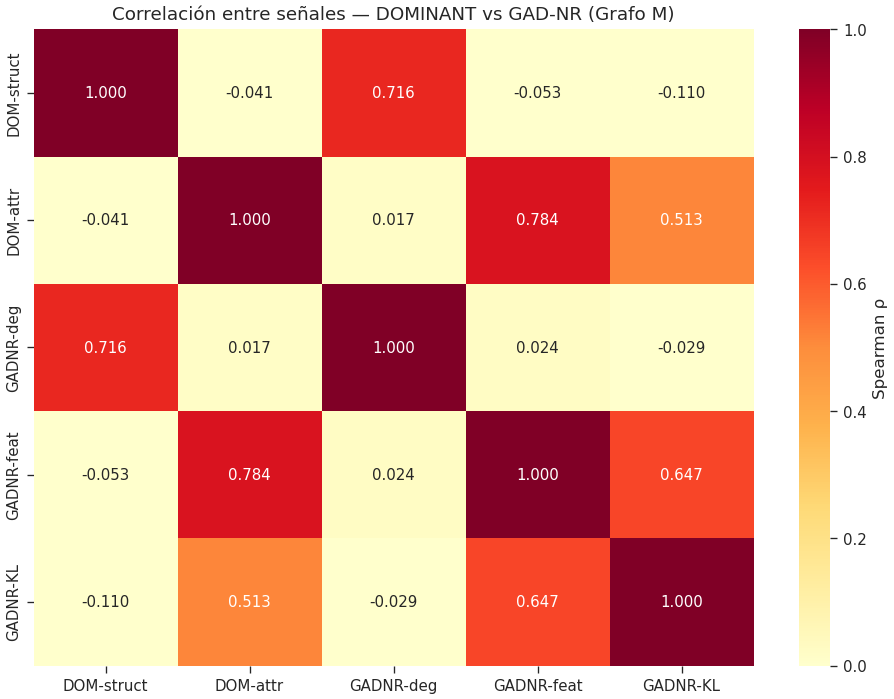

In [34]:
# Heatmap de correlación entre las 5 señales
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '05_signal_correlation_M.png')
plt.show()


In [35]:
# Acuerdo entre tipologías: ¿asignan el mismo tipo los dos modelos?
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo            3            8      0     541
Estructural        35          227     24     266
Mixta               0           11      0       6
Normal            496          288     11    9455


## 8. Guardado de resultados


In [36]:
cols_export = [
    'idx', 'member_id', 'name', 'city', 'state', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_M.csv')
print(f'Shape    : {scores_export.shape}')
print(f'Columnas : {list(scores_export.columns)}')


Guardado : ../data/results/scores_M.csv
Shape    : (11371, 20)
Columnas : ['idx', 'member_id', 'name', 'city', 'state', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h', 'type_dom', 'type_gadnr']


## Resumen del notebook

En este notebook hemos:

1. **Entrenado DOMINANT** y extraído  (estructural) y  (atributo).

2. **Entrenado GAD-NR** y extraído  (estructural),  (atributo)
   y  (joint-type — señal nueva sin equivalente en DOMINANT).

3. **Comparado señales equivalentes** estructural vs estructural y atributo vs atributo
   mediante correlación Spearman, solapamiento top-K y scatters de tipología por modelo.

4. **Analizado la señal joint-type** de GAD-NR de forma independiente, identificando
   los nodos invisibles para DOMINANT que solo GAD-NR detecta.

5. **Validado los candidatos del EDA** con las cinco señales.

Los resultados quedan en .
